NAME : MOHD RAZA, ROLL NO : 35, SECTION : 35

# Experiment No. 7
## Customer Segmentation using K-Means Clustering

**Aim:** To implement the K-Means Clustering algorithm on a real-world dataset for customer
segmentation and analyze customer groups based on purchasing behavior and demographic
characteristics.

### Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
print("Libraries imported successfully.")

Libraries imported successfully.


### Step 2: Load the Dataset
Replace `DATA_PATH` with your actual **Mall Customer Segmentation Dataset** CSV
(e.g. `Mall_Customers.csv` from Kaggle) if you have one. If the file isn't found, a
synthetic dataset with the same structure (CustomerID, Gender, Age, Annual Income,
Spending Score) is generated automatically so the notebook runs end-to-end.

In [5]:
import os

DATA_PATH = "/content/Mall_Customers.csv"   # <-- change this to your dataset path
df = pd.read_csv(DATA_PATH)
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


### Step 3: Data Preprocessing

In [6]:
print("Dataset info:\n")
df.info()

print("\nMissing values per column:\n")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Handle missing values (if any) and duplicates
df = df.drop_duplicates()
df = df.dropna()

# Basic statistics
df.describe()

Dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing values per column:

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
# Select relevant features for clustering
features = ["Annual Income (k$)", "Spending Score (1-100)"]
# You can also try including Age: features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

X = df[features].copy()
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### Step 4: Feature Scaling (Standardization)

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original feature ranges:")
print(X.describe().loc[["min", "max"]])

print("\nScaled feature stats (mean~0, std~1):")
print(pd.DataFrame(X_scaled, columns=features).describe().loc[["mean", "std"]])

Original feature ranges:
     Annual Income (k$)  Spending Score (1-100)
min                15.0                     1.0
max               137.0                    99.0

Scaled feature stats (mean~0, std~1):
      Annual Income (k$)  Spending Score (1-100)
mean       -2.131628e-16           -1.465494e-16
std         1.002509e+00            1.002509e+00


### Step 5: Determine Optimal K — Elbow Method & Silhouette Score

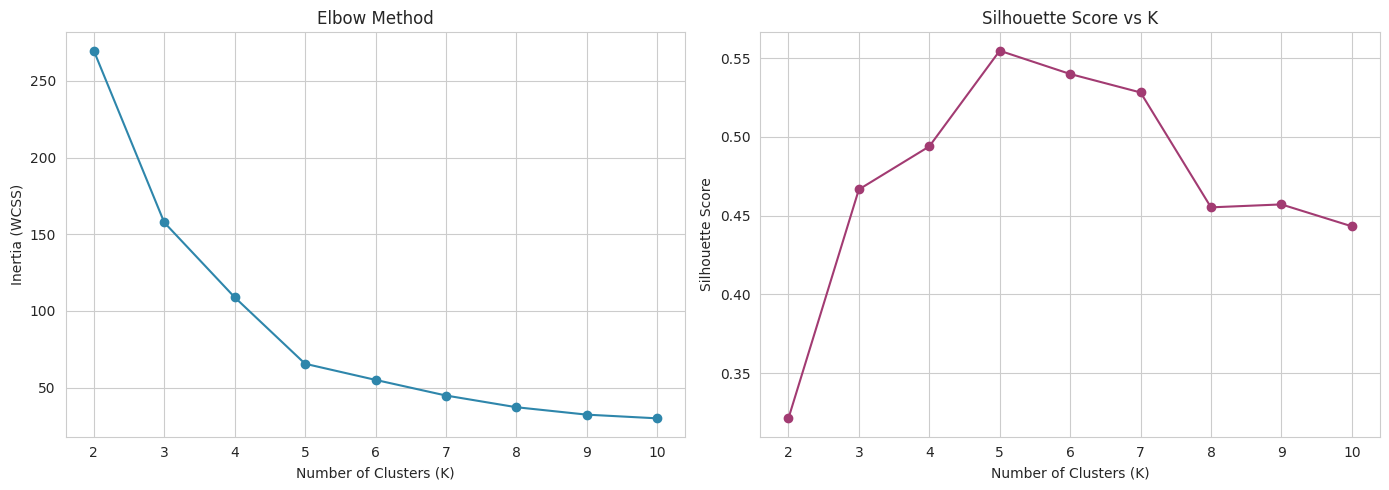

Silhouette scores: {2: np.float64(0.321), 3: np.float64(0.467), 4: np.float64(0.494), 5: np.float64(0.555), 6: np.float64(0.54), 7: np.float64(0.528), 8: np.float64(0.455), 9: np.float64(0.457), 10: np.float64(0.443)}

Best K by silhouette score: 5


In [9]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertia, marker="o", color="#2E86AB")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")

axes[1].plot(list(K_range), silhouette_scores, marker="o", color="#A23B72")
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k_by_silhouette = list(K_range)[int(np.argmax(silhouette_scores))]
print(f"Silhouette scores: {dict(zip(K_range, np.round(silhouette_scores, 3)))}")
print(f"\nBest K by silhouette score: {best_k_by_silhouette}")

### Step 6: Apply K-Means Clustering
Based on the Elbow curve (the "bend" point) and the Silhouette Score, choose K.
For the classic Mall Customers dataset this is typically **K = 5**; adjust
`OPTIMAL_K` below if your Elbow/Silhouette plot suggests a different value.

In [10]:
OPTIMAL_K = 5   # <-- set based on the elbow plot / silhouette score above

kmeans = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, df["Cluster"])
print(f"Final Silhouette Score for K={OPTIMAL_K}: {final_silhouette:.3f}")

df.head()

Final Silhouette Score for K=5: 0.555


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### Step 7: Visualize Clusters with Centroids

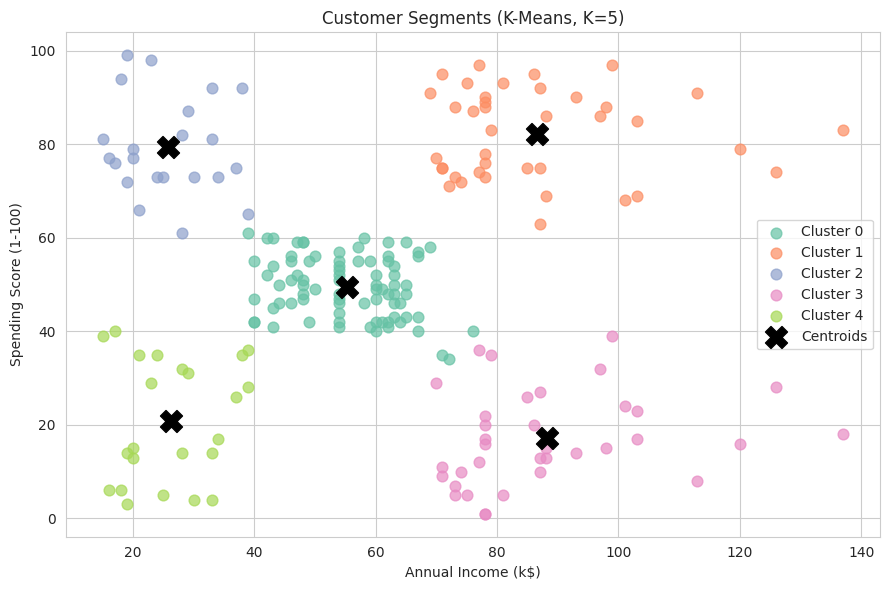

In [11]:
# Get centroids back in original (unscaled) feature space for interpretability
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

plt.figure(figsize=(9, 6))
palette = sns.color_palette("Set2", OPTIMAL_K)

for cluster_id in range(OPTIMAL_K):
    cluster_data = df[df["Cluster"] == cluster_id]
    plt.scatter(cluster_data[features[0]], cluster_data[features[1]],
                s=60, color=palette[cluster_id], label=f"Cluster {cluster_id}", alpha=0.7)

plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            s=250, c="black", marker="X", label="Centroids")

plt.title(f"Customer Segments (K-Means, K={OPTIMAL_K})")
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.legend()
plt.tight_layout()
plt.show()

### Step 8: Analyze Cluster Characteristics

In [12]:
cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
cluster_summary["Count"] = df["Cluster"].value_counts().sort_index()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


In [13]:
def label_segment(row):
    income, spend = row["Annual Income (k$)"], row["Spending Score (1-100)"]
    if income < 40 and spend < 40:
        return "Budget-Conscious (Low Income, Low Spend)"
    elif income < 40 and spend >= 60:
        return "Impulsive Spenders (Low Income, High Spend)"
    elif 40 <= income < 70:
        return "Average / Balanced Customers"
    elif income >= 70 and spend < 40:
        return "Cautious High-Earners (High Income, Low Spend)"
    else:
        return "Premium Target (High Income, High Spend)"

cluster_summary["Segment Label"] = cluster_summary.apply(label_segment, axis=1)
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Count,Segment Label
Cluster,,,,,
0,42.7,55.3,49.5,81,Average / Balanced Customers
1,32.7,86.5,82.1,39,"Premium Target (High Income, High Spend)"
2,25.3,25.7,79.4,22,"Impulsive Spenders (Low Income, High Spend)"
3,41.1,88.2,17.1,35,"Cautious High-Earners (High Income, Low Spend)"
4,45.2,26.3,20.9,23,"Budget-Conscious (Low Income, Low Spend)"


### Step 9: Suggested Marketing Strategy per Segment

In [14]:
strategy_map = {
    "Budget-Conscious (Low Income, Low Spend)":
        "Offer discounts, loyalty points, and value bundles to increase engagement.",
    "Impulsive Spenders (Low Income, High Spend)":
        "Promote flash sales, limited-time offers, and easy installment/credit options.",
    "Average / Balanced Customers":
        "Use standard promotions and periodic engagement campaigns to nudge loyalty.",
    "Cautious High-Earners (High Income, Low Spend)":
        "Highlight premium quality, exclusivity, and personalized recommendations to earn trust.",
    "Premium Target (High Income, High Spend)":
        "Prioritize VIP programs, early access to new products, and premium/luxury upselling.",
}

for _, row in cluster_summary.iterrows():
    label = row["Segment Label"]
    print(f"- {label}: {strategy_map[label]}")

- Average / Balanced Customers: Use standard promotions and periodic engagement campaigns to nudge loyalty.
- Premium Target (High Income, High Spend): Prioritize VIP programs, early access to new products, and premium/luxury upselling.
- Impulsive Spenders (Low Income, High Spend): Promote flash sales, limited-time offers, and easy installment/credit options.
- Cautious High-Earners (High Income, Low Spend): Highlight premium quality, exclusivity, and personalized recommendations to earn trust.
- Budget-Conscious (Low Income, Low Spend): Offer discounts, loyalty points, and value bundles to increase engagement.


### Step 10: Summary
Run the cell below for a concise recap of the clustering results.

In [15]:
print("CLUSTERING SUMMARY")
print("-" * 45)
print(f"Optimal number of clusters (K): {OPTIMAL_K}")
print(f"Final Silhouette Score: {final_silhouette:.3f}")
print(f"Total customers analyzed: {len(df)}")
print("\nSegment sizes:")
print(df['Cluster'].value_counts().sort_index().to_string())
print("\nCustomer segmentation via K-Means groups shoppers by income and spending")
print("behavior, enabling targeted marketing, better resource allocation, and")
print("improved customer retention strategies for the business.")

CLUSTERING SUMMARY
---------------------------------------------
Optimal number of clusters (K): 5
Final Silhouette Score: 0.555
Total customers analyzed: 200

Segment sizes:
Cluster
0    81
1    39
2    22
3    35
4    23

Customer segmentation via K-Means groups shoppers by income and spending
behavior, enabling targeted marketing, better resource allocation, and
improved customer retention strategies for the business.
